Tratamento e Visualização de Dados - FTIR
===

**Autor:** [Mateus de Jesus Mendes](mailto:mateus25032@ilum.cnpem.br)

##### **Funções**

Importação de bibliotecas:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Plot singular:

In [2]:
def ftir_plot(file_path=None, sample_name=None):
    """
    Gera plots (Matplotlib e Plotly) de um único espectro FTIR.

    ### Parâmetros

    - file_path (str): Caminho do arquivo contendo dados de espectroscopia FTIR.
    - sample_name (object): Nome da amostra.
    """
    
    file_path = file_path

    data = []
    with open(file_path, "r") as f:
        for line in f:
            if line.startswith("##") or line.strip() == "": # Ignora os metadados
                continue
            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    x, y = map(float, parts[:2])
                    data.append((x, y))
                except:
                    continue

    df = pd.DataFrame(data, columns=["Wavenumber", "Transmittance"])

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    plt.plot(df["Wavenumber"], df["Transmittance"], linewidth=1)
    plt.gca().invert_xaxis()  # Convenção FTIR
    plt.xlabel("Número de ondas (cm$^{-1}$)")
    plt.ylabel("Transmitância (%)")
    plt.title(f"Espectro FTIR — {sample_name}")
    plt.show()

    # Plotly
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df["Wavenumber"],
        y=df["Transmittance"],
        mode='lines',
        line=dict(width=1),
        name="FTIR"
    ))

    fig.update_layout(
        title=f"Espectro FTIR — {sample_name}",
        xaxis=dict(title="Número de ondas (cm$^{-1}$)", autorange="reversed"), # Convenção FTIR
        yaxis=dict(title="Transmitância (%)"),
        template="simple_white",
        width=800,
        height=500
    )

    fig.show()

Plot conjunto (*overlayed*):

In [3]:
def ftir_overlay(file_paths, sample_names=None):
    """
    Gera plots (Matplotlib e Plotly) de múltiplos espectros FTIR em overlay.

    ### Parâmetros

    - file_paths (list of str): Lista dos caminhos dos arquivos contendo dados de espectroscopia FTIR.
    - sample_names (list of str, optional): Nomes das amostras.
    """

    # Se não passar sample_name, usa o nome dos arquivos
    if sample_names is None:
        sample_names = [fp.split("/")[-1] for fp in file_paths]

    # Matplotlib 
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    for fp, label in zip(file_paths, sample_names):
        data = []
        with open(fp, "r") as f:
            for line in f:
                if line.startswith("##") or line.strip() == "":
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data.append((x, y))
                    except:
                        continue

        df = pd.DataFrame(data, columns=["Wavenumber", "Transmittance"])
        plt.plot(df["Wavenumber"], df["Transmittance"], linewidth=1, label=label)

    plt.gca().invert_xaxis()  # Convenção FTIR
    plt.xlabel("Número de ondas (cm$^{-1}$)")
    plt.ylabel("Transmitância (%)")
    plt.title("Overlay dos Espectros FTIR")
    plt.legend(['GO', 'rGO'])
    plt.show()

    # Plotly
    fig = go.Figure()

    for fp, label in zip(file_paths, sample_names):
        data = []
        with open(fp, "r") as f:
            for line in f:
                if line.startswith("##") or line.strip() == "":
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data.append((x, y))
                    except:
                        continue

        df = pd.DataFrame(data, columns=["Wavenumber", "Transmittance"])
        fig.add_trace(go.Scatter(
            x=df["Wavenumber"],
            y=df["Transmittance"],
            mode='lines',
            line=dict(width=1),
            name=label
        ))

    fig.update_layout(
        title="Overlay de Espectros FTIR",
        xaxis=dict(title="Número de ondas (cm$^{-1}$)", autorange="reversed"),
        yaxis=dict(title="Transmitância (%)"),
        template="simple_white",
        width=800,
        height=500
    )

    fig.show()

# FTIR - GO

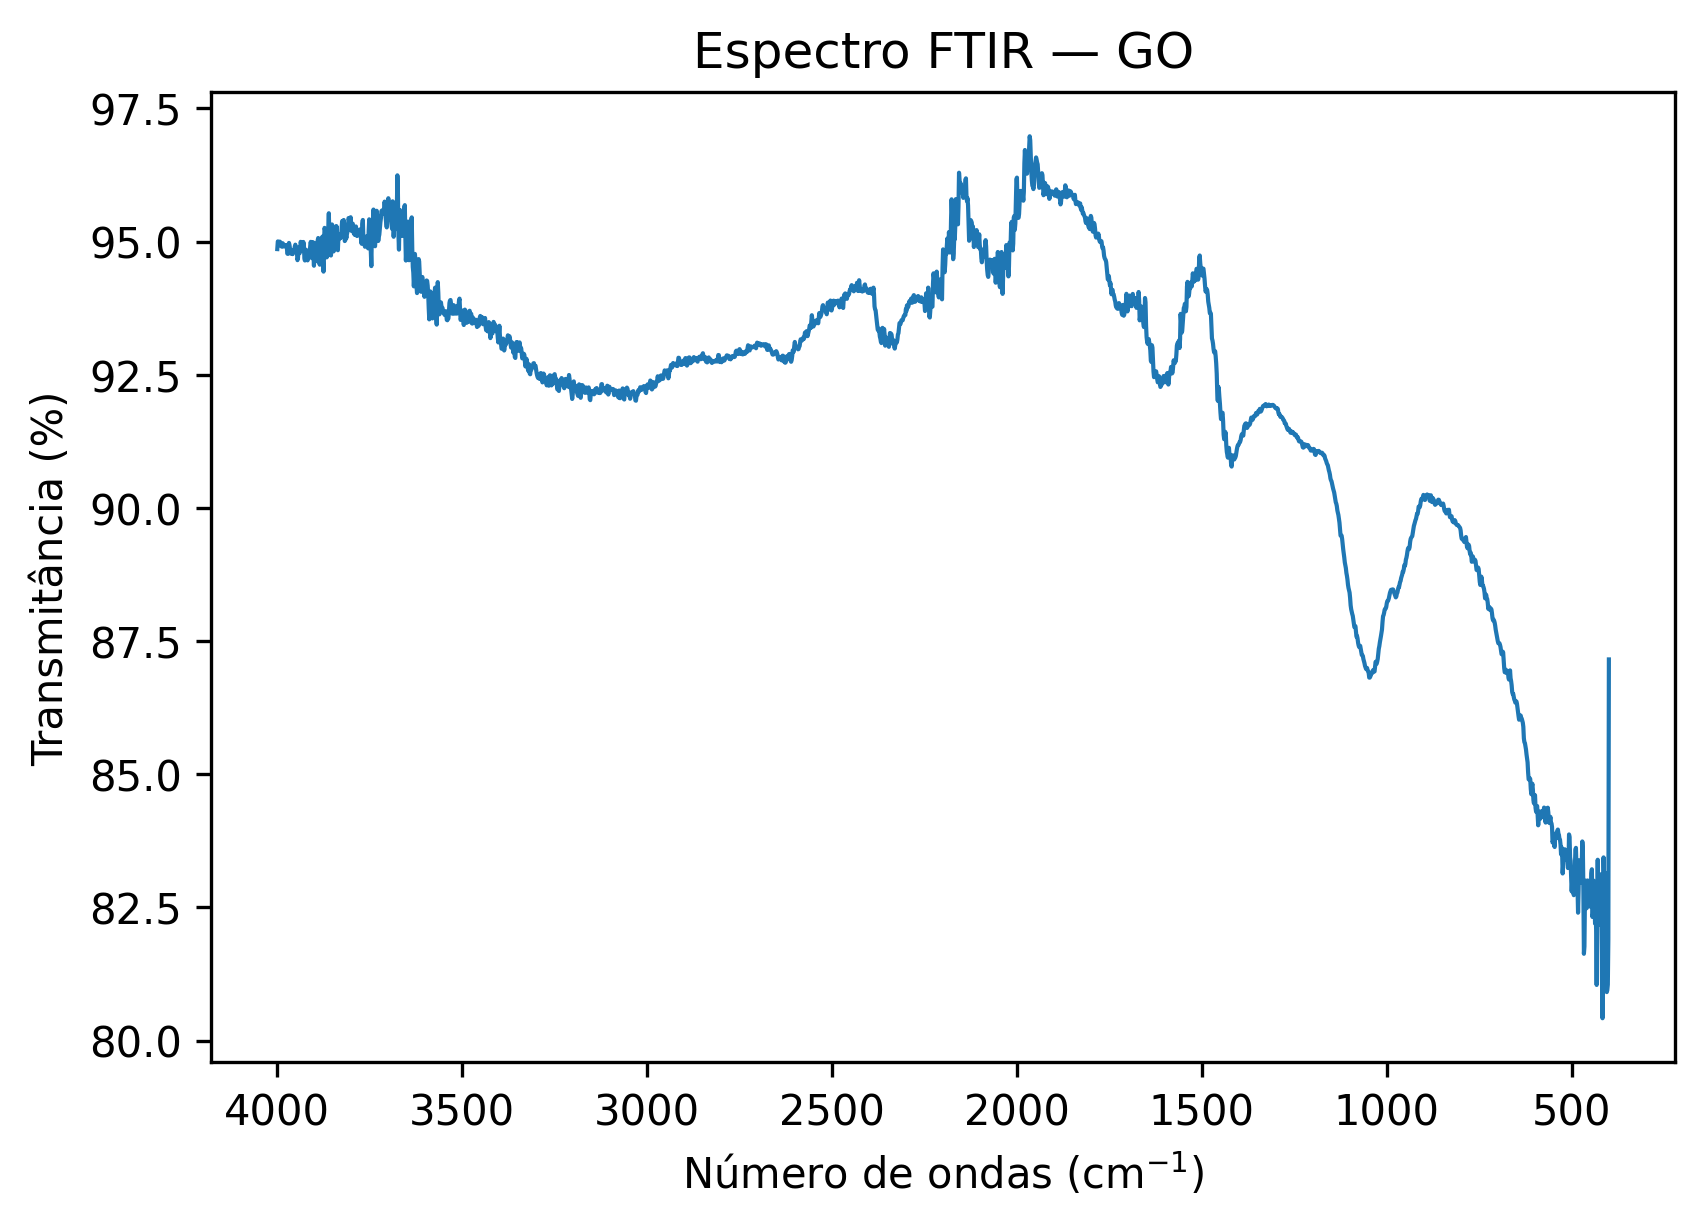

In [4]:
ftir_plot('GO_MMV.txt', 'GO')

# FTIR - rGO

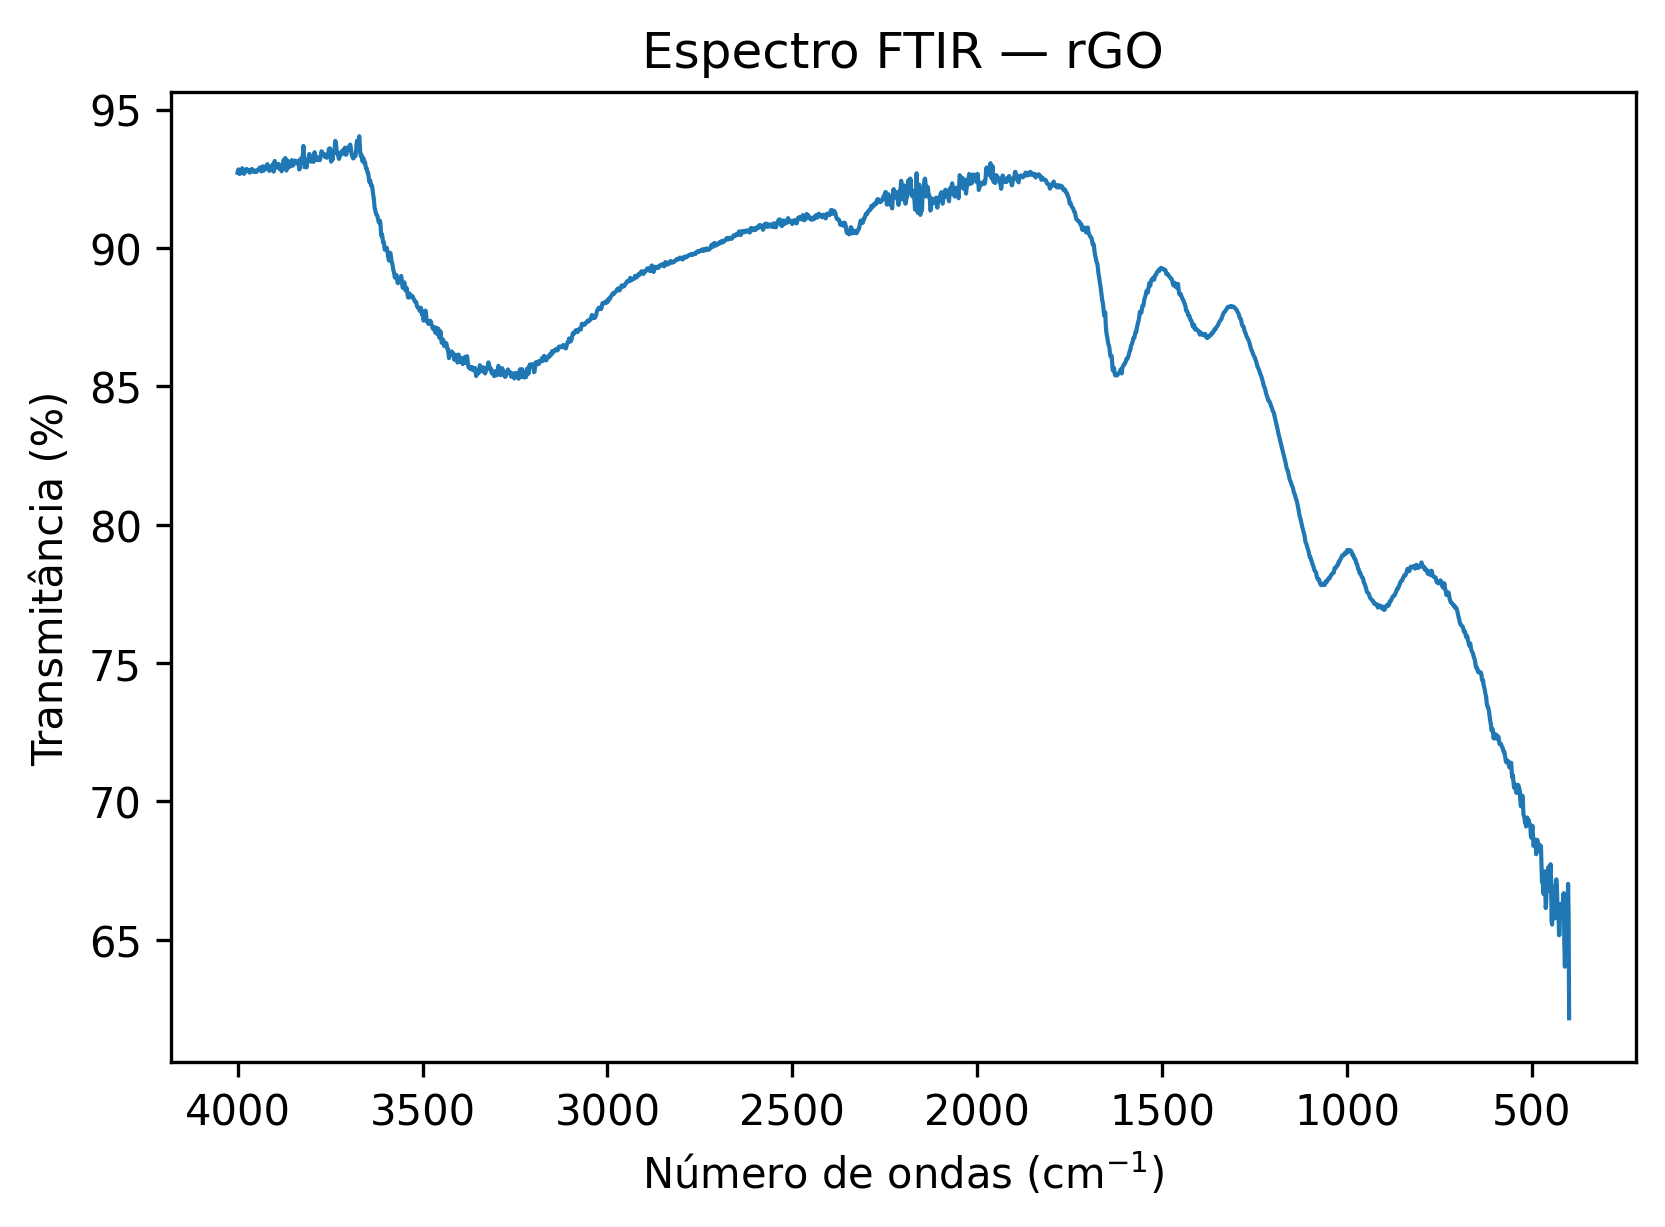

In [5]:
ftir_plot('rGO_MMV.txt', 'rGO')

# *Overlay*

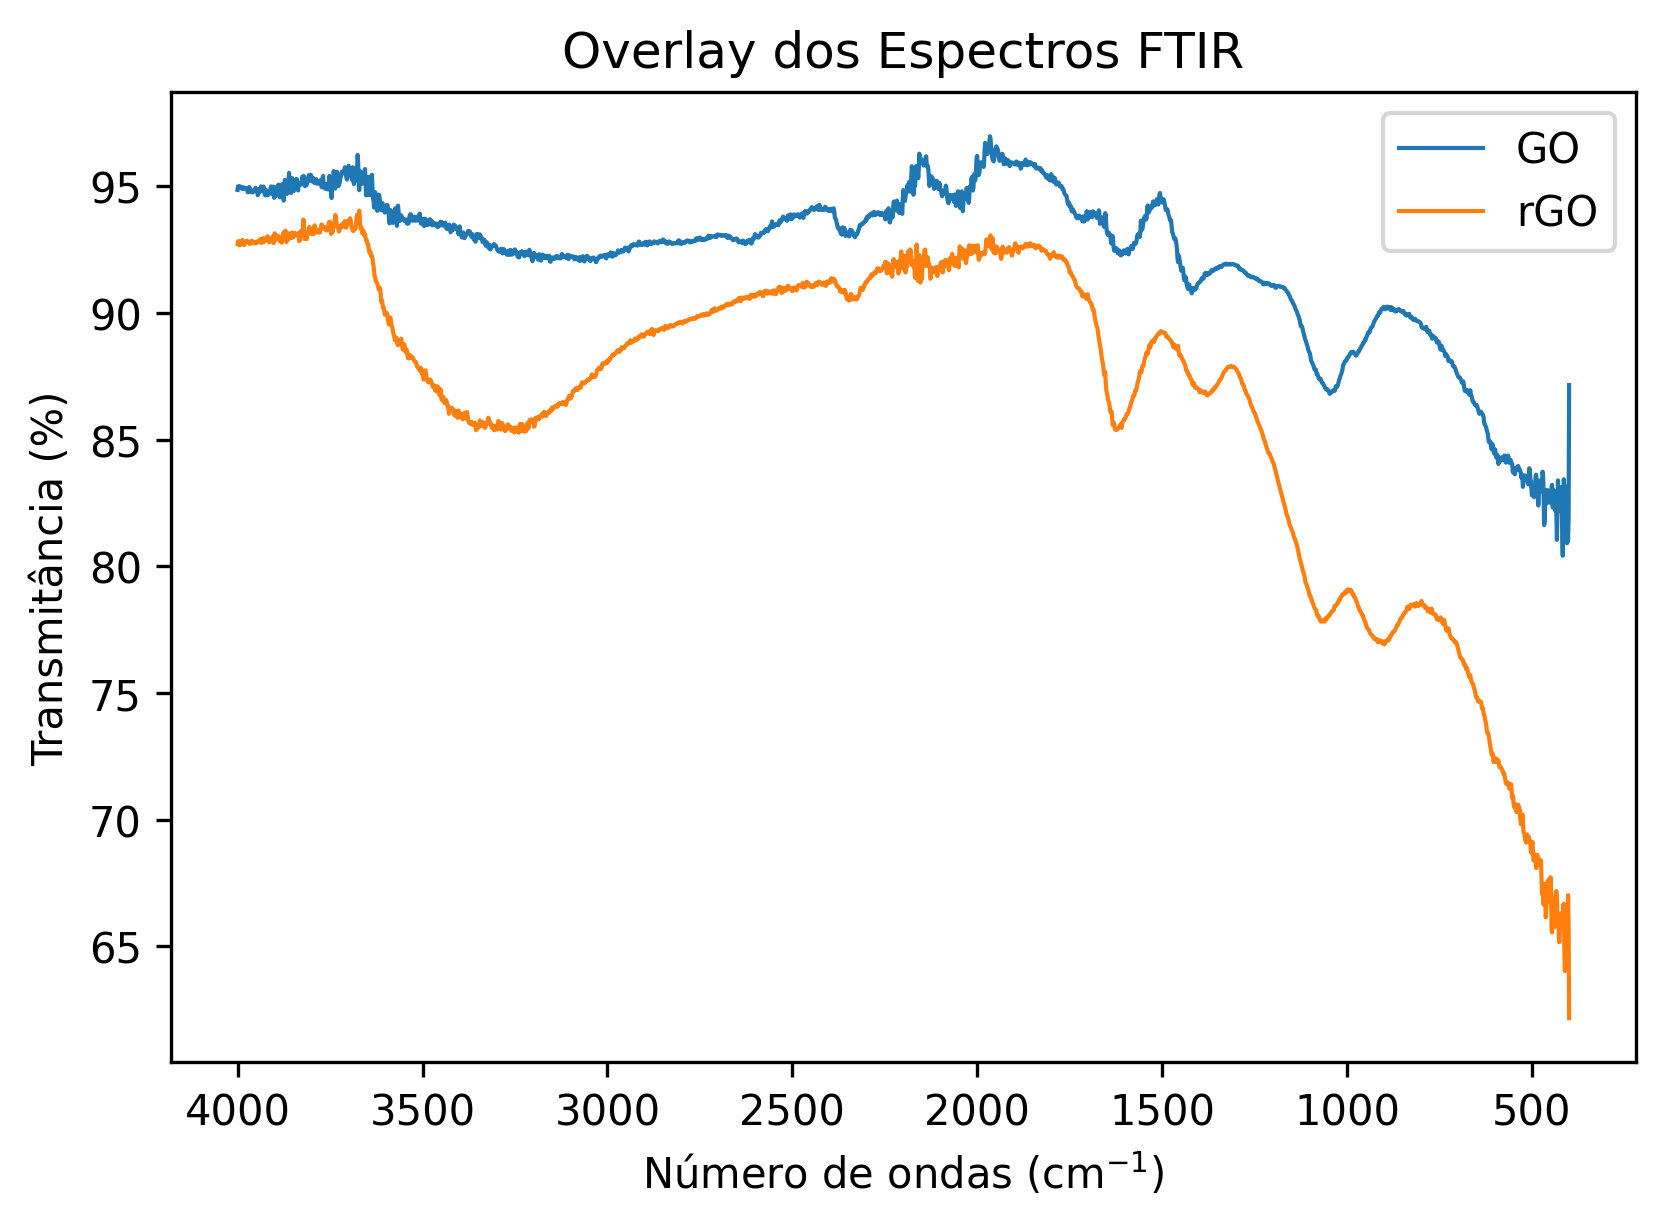

In [6]:
ftir_overlay(('GO_MMV.txt', 'rGO_MMV.txt'))